# Imports and utility

In [1]:

!pip install -q --upgrade keras-hub
#d8f53b61969adf7ee621c216f680b707
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import keras_hub
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                     BatchNormalization, Activation, GlobalAveragePooling2D)
from tensorflow.keras.applications import VGG16, VGG19, ResNet50, ResNet152, EfficientNetB0, DenseNet121, InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, LearningRateScheduler, ModelCheckpoint
from tensorflow.keras import optimizers
import keras_hub

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # 0 = todo, 1 = INFO, 2 = WARNING, 3 = ERROR
tf.get_logger().setLevel('ERROR')

train_dir = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/train'
val_dir = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/val'
test_dir = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/test'
auto_test = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/auto_test'
cat_dir = '/kaggle/input/cat-knee/clean'

IMG_SIZE = (224, 224)
BATCH_SIZE = 8
SEED = 66


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 876.5/876.5 kB 38.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.18.1 requires keras-hub==0.18.1, but you have keras-hub 0.21.1 which is incompatible.


In [2]:
import pandas as pd
import os

def create_dataframe_from_directory(base_dir, regression=False):
    data = []
    for label_str in sorted(os.listdir(base_dir)):
        label_path = os.path.join(base_dir, label_str)
        if not os.path.isdir(label_path):
            continue
        label = float(label_str) if regression else label_str
        for fname in os.listdir(label_path):
            data.append({
                'filename': os.path.join(label_str, fname),  # ruta relativa
                'label': label  # KL debe ser numérico para regresión
            })
    return pd.DataFrame(data)

In [3]:
from sklearn.metrics import mean_absolute_error, accuracy_score
import numpy as np
import tensorflow as tf

class CatValidationCallback(tf.keras.callbacks.Callback):
    def __init__(self, cat_generator, regresion=False, filepath='best_model_cat.keras'):
        super().__init__()
        self.cat_generator = cat_generator
        self.epoch_metrics = []
        self.regresion = regresion
        self.filepath = filepath
        # Inicializamos best_score y best_loss
        if regresion:
            self.best_score = 0.0    # queremos maximizar accuracy
            self.best_loss  = np.inf # y minimizar MAE
        else:
            self.best_score = 0.0    # queremos maximizar accuracy
            self.best_loss  = np.inf # y minimizar categorical loss

    def on_epoch_end(self, epoch, logs=None):
        # Predicciones
        preds = self.model.predict(self.cat_generator, verbose=0)

        if self.regresion:
            # Regresión: calculamos MAE + accuracy sobre clases redondeadas
            y_pred = preds.flatten()
            y_true = self.cat_generator.labels
            loss = mean_absolute_error(y_true, y_pred)
            y_pred_class = np.clip(np.round(y_pred), 0, 4).astype(int)
            y_true_class = np.clip(np.round(y_true), 0, 4).astype(int)
            acc = accuracy_score(y_true_class, y_pred_class)
            score = acc
        else:
            # Clasificación: evalúa el loss y la accuracy
            loss, acc = self.model.evaluate(self.cat_generator, verbose=0)
            preds_class = np.argmax(preds, axis=1)
            y_true = self.cat_generator.classes
            # para consistency, recalculamos acc con sklearn
            acc = accuracy_score(y_true, preds_class)
            score = acc

        # Guardar métricas
        self.epoch_metrics.append({
            'epoch': epoch + 1,
            'val_cat_loss': loss,
            'val_cat_accuracy': acc
        })

        # Mostrar por consola
        tag = "MAE" if self.regresion else "Loss"
        print(f"🐾 [Cat Val] {tag}: {loss:.4f} | Accuracy: {acc:.4f}")

        # Comprobamos mejora: primero por score, si empate por loss
        improved = False
        if score > self.best_score:
            improved = True
        elif score == self.best_score and loss < self.best_loss:
            improved = True

        # Si mejoró, guardamos modelo y actualizamos referencias
        if improved:
            self.best_score = score
            self.best_loss  = loss
            self.model.save(self.filepath)
            print(f"📦 Modelo mejorado guardado en {self.filepath}")


In [4]:
from tensorflow.keras.callbacks import ModelCheckpoint

def get_callbacks(regression=False, cat_gen=None, finetuning=False):
  if cat_gen:
      cat_val_cb = CatValidationCallback(cat_gen, regresion=regression)
  if finetuning:
      earlystopping = 5
      patience = 3
  else:
      earlystopping = 10
      patience = 3
      

  checkpoint_cb = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_accuracy',         # nombre de la métrica a monitorizar
    mode='max',                     # porque buscamos la mayor precisión
    save_best_only=True,
    save_weights_only=False,
    verbose=1
  )
  checkpoint_cb_reg = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
  )
  if regression:
    callbacks = [
        EarlyStopping(patience=earlystopping, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.5, patience=patience, verbose=1),
        checkpoint_cb_reg
    ]
  else:
    callbacks = [
        EarlyStopping(patience=earlystopping, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.5, patience=patience, verbose=1),
        checkpoint_cb
    ]
  if cat_gen:
      callbacks.append(cat_val_cb)
  return callbacks


In [5]:
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def _get_label_map(y_true, y_pred, generator=None, default_prefix='KL'):
    """
    Genera label_map automáticamente.
    - Si el generador tiene class_indices (clasificación Keras), los usa.
    - Si no, extrae las clases únicas de y_true y y_pred.
    - Si todo falla, crea labels 'KL 0', 'KL 1', ..., según número de clases.
    """
    # Caso Keras classification_generator
    if generator is not None and hasattr(generator, 'class_indices'):
        # Ordenar por índice
        sorted_items = sorted(generator.class_indices.items(), key=lambda x: x[1])
        return [name for name, _ in sorted_items]
    
    # Extraer clases únicas
    classes = np.unique(np.concatenate((y_true, y_pred)))
    # Si son enteros consecutivos desde 0 a n-1
    if np.array_equal(classes, np.arange(len(classes))):
        return [f'{default_prefix} {i}' for i in classes]
    # En caso de etiquetas no enteras o desordenadas
    return [str(c) for c in classes]

def evaluate_classification(y_true, y_pred, label_map=None, digits=4, title_suffix=''):
    """
    Reporte de clasificación + matriz de confusión.
    """
    if label_map is None:
        label_map = _get_label_map(y_true, y_pred)
    # Reporte
    print(classification_report(
        y_true, y_pred,
        target_names=label_map,
        digits=digits
    ))
    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=label_map, yticklabels=label_map
    )
    plt.xlabel('Predicción')
    plt.ylabel('Etiqueta verdadera')
    if title_suffix:
        plt.title(title_suffix)
    plt.show()

def evaluate_model(model, regression, generator, label_map=None, digits=4):
    """
    Elige el modo de evaluación y asegura que label_map siempre se resuelva.
    """
    # Predicciones crudas
    preds = model.predict(generator)
    
    if regression:
        # Convertir a clases
        if hasattr(generator, 'labels'):
            y_true_cont = np.array(generator.labels).flatten()
        else:
            y_true_cont = np.array(generator.classes).flatten()
        y_pred_cont = np.array(preds).flatten()
        
        # MAE
        mae = mean_absolute_error(y_true_cont, y_pred_cont)
        print(f"Mean Absolute Error (MAE): {mae:.{digits}f}\n")
        plt.figure(figsize=(6,6))
        # Dispersión
        plt.scatter(y_pred_cont, y_true_cont, alpha=0.5)
        # Línea de identidad
        mn = min(y_true_cont.min(), y_pred_cont.min())
        mx = max(y_true_cont.max(), y_pred_cont.max())
        plt.plot([mn, mx], [mn, mx], 'r--', linewidth=1)
        # Etiquetas
        plt.xlabel("Predicción (decimal)")
        plt.ylabel("Valor verdadero")
        plt.title("Scatter: Predicción vs Valor verdadero")
        plt.grid(True)
        plt.show()

        y_true_class = np.clip(np.round(y_true_cont).astype(int), 0, None)
        y_pred_class = np.clip(np.round(y_pred_cont).astype(int), 0, None)
        # Obtener label_map adaptado al rango observado
        if label_map is None:
            max_label = max(y_true_class.max(), y_pred_class.max())
            label_map = [f'KL {i}' for i in range(max_label + 1)]
        
        evaluate_classification(
            y_true=y_true_class,
            y_pred=y_pred_class,
            label_map=label_map,
            digits=digits,
        )
    else:
        # Clasificación softmax u otra salida multiclase
        y_pred = np.argmax(preds, axis=1)
        y_true = generator.classes
        
        if label_map is None:
            label_map = _get_label_map(y_true, y_pred, generator=generator)
        
        evaluate_classification(
            y_true=y_true,
            y_pred=y_pred,
            label_map=label_map,
            digits=digits
        )

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd

def get_datagen(
    tarea: int,
    path: str,
    regression: bool = False,
    IMG_SIZE: tuple = (224, 224),
    BATCH_SIZE: int = 32,
    SEED: int = 42,
    augment: bool = False,
    balanced: bool = False                  # ← Parámetro de balanceo
):
    """
    Generador de imágenes para clasificación y regresión con distintos esquemas de tarea,
    opcionalmente balanceando el número de muestras por etiqueta entera.
    """
    # 1. Configurar ImageDataGenerator
    if augment:
        datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=10,
            width_shift_range=0.1,
            height_shift_range=0.1,
            zoom_range=0.1,
            horizontal_flip=True
        )
        shuffle = True
    else:
        datagen = ImageDataGenerator(rescale=1./255)
        shuffle = False

    # 2. Cargar DataFrame y procesar etiquetas como ints
    df = create_dataframe_from_directory(path, regression=regression)
    df_proc = df.copy()
    df_proc['label'] = df_proc['label'].astype(int)

    # 3. Aplicar esquema de tarea (igual que antes)
    if tarea == 0:
        pass
    elif tarea == 1:
        df_proc['label'] = df_proc['label'].apply(
            lambda x: 0 if x in [0,1,2] else 1 if x == 3 else 2
        )
    elif tarea in [2,3,4,5]:
        target = tarea - 1
        df_proc = df_proc[df_proc['label'].isin([0, target])]
        df_proc['label'] = df_proc['label'].apply(lambda x: 1 if x == target else 0)
    else:
        raise ValueError("tarea debe ser un entero entre 0 y 5.")

    # 4. Muestreo balanceado POR ETIQUETA ENTERA (tanto clasificación como regresión)
    if balanced:
        counts = df_proc['label'].value_counts()
        max_count = counts.max()
        balanced_frames = []
        for cls, cnt in counts.items():
            df_cls = df_proc[df_proc['label'] == cls]
            if cnt < max_count:
                # muestreo con reemplazo
                df_resampled = df_cls.sample(max_count, replace=True, random_state=SEED)
            else:
                df_resampled = df_cls
            balanced_frames.append(df_resampled)
        df_proc = pd.concat(balanced_frames).reset_index(drop=True)

    # 5. Preparar salida para regresión o clasificación
    if regression:
        # Convertir a float para class_mode='raw'
        df_proc['label'] = df_proc['label'].astype(float)
        return datagen.flow_from_dataframe(
            dataframe=df_proc,
            directory=path,
            x_col='filename',
            y_col='label',
            target_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            class_mode='raw',
            shuffle=shuffle,
            seed=SEED
        )

    # Clasificación: convertir labels a str para 'categorical'
    df_proc['label'] = df_proc['label'].astype(str)
    return datagen.flow_from_dataframe(
        dataframe=df_proc,
        directory=path,
        x_col='filename',
        y_col='label',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=shuffle,
        seed=SEED
    )


In [7]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras

def get_datagen_df(
    tarea: int,
    path: str,
    regression: bool = False,
    IMG_SIZE: tuple = (224, 224),
    BATCH_SIZE: int = 32,
    SEED: int = 42,
    augment: bool = False,
    balanced: bool = False
) -> tf.data.Dataset:
    """
    Pipeline de datos basado en tf.data.Dataset que emula:
      - flow_from_dataframe con ImageDataGenerator
      - Esquemas de tarea (0–5)
      - Aumentación opcional
      - Balanceo de clases replicando filas en pandas
      - Salida para clasificación (one-hot) o regresión (float)
    """
    # 1. Crear DataFrame y etiquetas
    df = create_dataframe_from_directory(path, regression=regression)
    df_proc = df.copy()
    df_proc['label'] = df_proc['label'].astype(int)

    # 2. Aplicar esquema de tarea
    if tarea == 0:
        pass
    elif tarea == 1:
        df_proc['label'] = df_proc['label'].apply(
            lambda x: 0 if x in [0,1,2] else 1 if x == 3 else 2
        )
    elif tarea in [2,3,4,5]:
        target = tarea - 1
        df_proc = df_proc[df_proc['label'].isin([0, target])]
        df_proc['label'] = df_proc['label'].apply(lambda x: 1 if x == target else 0)
    else:
        raise ValueError("tarea debe ser un entero entre 0 y 5.")

    # 3. Balanceo con pandas (muestreo con reemplazo)
    if balanced:
        counts = df_proc['label'].value_counts()
        max_count = counts.max()
        frames = []
        for cls, cnt in counts.items():
            df_cls = df_proc[df_proc['label'] == cls]
            if cnt < max_count:
                df_cls = df_cls.sample(max_count, replace=True, random_state=SEED)
            frames.append(df_cls)
        df_proc = pd.concat(frames).reset_index(drop=True)

    # 4. Preparar rutas de ficheros y etiquetas
    file_paths = df_proc['filename'].apply(lambda f: os.path.join(path, f)).values
    labels = df_proc['label'].values
    if regression:
        labels = labels.astype(np.float32)
    else:
        labels = labels.astype(np.int32)
        num_classes = df_proc['label'].nunique()

    # 5. Construir Dataset
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))

    # 6. Capa de aumentación si procede
    if augment:
        data_augment = keras.Sequential([
            keras.layers.experimental.preprocessing.RandomFlip("horizontal", seed=SEED),
            keras.layers.experimental.preprocessing.RandomRotation(0.1, seed=SEED),
            keras.layers.experimental.preprocessing.RandomZoom(0.1, seed=SEED),
            keras.layers.experimental.preprocessing.RandomTranslation(0.1, 0.1, seed=SEED),
        ])
    else:
        data_augment = None

    # 7. Función de carga y preprocesado
    def _load_and_preprocess(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image = tf.image.resize(image, IMG_SIZE)
        image = image / 255.0
        if data_augment:
            image = data_augment(image)
        if regression:
            return image, label
        else:
            return image, tf.one_hot(label, depth=num_classes)

    # 8. Mezcla, batching y prefetch
    ds = ds.shuffle(buffer_size=len(file_paths), seed=SEED)
    ds = ds.map(_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def get_data_split_generators(
    tarea: int,
    path: str,
    regression: bool = False,
    test_size: float = 0,
    val_size: float = 0.3,
    random_state: int = 42,
    augment: bool = False,
    balanced: bool = False,
    IMG_SIZE: tuple = (224, 224),
    BATCH_SIZE: int = 32,
    SEED: int = 42
):
    """
    Divide en train/val/test, aplica transformaciones de etiquetas según tarea,
    y devuelve un generador (datagen) por cada split. Si balanced=True, 
    re-muestrea el set de entrenamiento para tener igual número de muestras por clase (oversampling).

    Parámetros:
        tarea        – entero 0–8 que define esquema de etiquetas.
        path         – ruta al directorio de imágenes.
        regression   – True para regresión, False para clasificación.
        test_size    – proporción de datos para test (0–1).
        val_size     – proporción de datos para validación (0–1).
        random_state – semilla aleatoria.
        augment      – True para data augmentation solo en entrenamiento.
        balanced     – True para balancear clases en entrenamiento (oversampling).
        IMG_SIZE     – tupla (alto, ancho) para resize.
        BATCH_SIZE   – tamaño de lote.
        SEED         – semilla para los generators.

    Retorna:
        train_gen, val_gen, test_gen
    """
    # 1. Carga DataFrame base
    df = create_dataframe_from_directory(path, regression=False)
    df['label'] = df['label'].astype(int)

    # 2. Split train+val vs test
    if test_size > 0.0:
        df_trainval, df_test = train_test_split(
            df,
            test_size=test_size,
            random_state=random_state,
            stratify=df['label']
        )
    else:
        df_trainval = df
        df_test = None

    # 3. Split train vs val
    val_rel = val_size / (1 - test_size)
    df_train, df_val = train_test_split(
        df_trainval,
        test_size=val_rel,
        random_state=random_state,
        stratify=df_trainval['label']
    )

    # 4. Transformación de etiquetas según tarea
    def transform_labels(df_subset: pd.DataFrame) -> (pd.DataFrame, str):
        df_proc = df_subset.copy()
        if tarea == 0:
            pass
        elif tarea == 1:
            df_proc['label'] = df_proc['label'].map(
                lambda x: 0 if x in [0,1,2] else 1 if x == 3 else 2
            )
            print("[DEBUG] TAREA 1")
        elif tarea in [2,3,4,5]:
            target = tarea - 1
            df_proc = df_proc[df_proc['label'].isin([0, target])]
            df_proc['label'] = df_proc['label'].map(lambda x: 1 if x == target else 0)
        elif tarea == 6:
            df_proc['label'] = df_proc['label'].map(lambda x: 0 if x == 0 else 1)
        elif tarea == 7:
            df_proc['label'] = df_proc['label'].map(lambda x: 0 if x in [0,1] else 1)
        elif tarea == 8:
            df_proc['label'] = df_proc['label'].map(lambda x: 0 if x in [0,1] else 1)
        else:
            raise ValueError("tarea debe ser un entero entre 0 y 8.")

        if regression:
            df_proc['label'] = df_proc['label'].astype(float)
            class_mode = 'raw'
        else:
            df_proc['label'] = df_proc['label'].astype(str)
            class_mode = 'categorical'

        return df_proc.reset_index(drop=True), class_mode

    # 4.1 Aplicar transformación de etiquetas a cada split
    df_train, class_mode = transform_labels(df_train)
    df_val, _       = transform_labels(df_val)
    if test_size > 0:
        df_test, _   = transform_labels(df_test)

    # 5. Si balanced=True, re-muestrear df_train para balancear clases (OVERSAMPLING)
    if balanced:
        # Contar cuántas muestras tiene cada clase en el train
        conteos = df_train['label'].value_counts()
        max_count = int(conteos.max())

        # Para cada clase, tomar muestras con reemplazo hasta llegar a max_count
        df_train_bal = (
            df_train
            .groupby('label', group_keys=False)
            .apply(lambda g: g.sample(n=max_count, replace=True, random_state=random_state))
        ).reset_index(drop=True)

        print(f"[DEBUG] balanced=True → cada clase ahora tiene {max_count} muestras. Total train = {len(df_train_bal)}")
        df_train = df_train_bal

    # 6. Configuración de ImageDataGenerator para cada split
    # Entrenamiento
    if augment:
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=10,
            width_shift_range=0.1,
            height_shift_range=0.1,
            zoom_range=0.1,
            horizontal_flip=True
        )
        train_shuffle = True
    else:
        train_datagen = ImageDataGenerator(rescale=1./255)
        train_shuffle = False

    # Validación y prueba sin augment
    eval_datagen = ImageDataGenerator(rescale=1./255)

    # 7. Creación de los generators
    train_gen = train_datagen.flow_from_dataframe(
        dataframe=df_train,
        directory=path,
        x_col='filename',
        y_col='label',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode=class_mode,
        shuffle=train_shuffle,
        seed=SEED
    )

    val_gen = eval_datagen.flow_from_dataframe(
        dataframe=df_val,
        directory=path,
        x_col='filename',
        y_col='label',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode=class_mode,
        shuffle=False,
        seed=SEED
    )

    if test_size > 0:
        test_gen = eval_datagen.flow_from_dataframe(
            dataframe=df_test,
            directory=path,
            x_col='filename',
            y_col='label',
            target_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            class_mode=class_mode,
            shuffle=False,
            seed=SEED
        )
    else:
        test_gen = None

    return train_gen, val_gen, test_gen


## Experimentos a realizar

Normal 
012-3-4
0-1
0-2
0-3
0-4

In [9]:
def cnn_pequeno(num_classes = 5, regression=False):
    activation = 'linear' if regression else 'softmax'
    model = models.Sequential([
        layers.Conv2D(16, (3,3), activation='relu',
                      input_shape=(224,224,3)),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(num_classes, activation=activation)
    ])
    return model

In [10]:
def cnn_mediana(num_classes, regression=False):
    activation = 'linear' if regression else 'softmax'
    model = models.Sequential([
        # Primera capa convolucional
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(224,224,3)),
        MaxPooling2D((2, 2)),
        # Segunda capa convolucional
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        # Aplanamiento y capas densas
        Flatten(),
        Dense(128, activation='relu'),
        Dense(num_classes, activation=activation)
    ])
    return model

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, BatchNormalization, MaxPooling2D, Dropout,
    Flatten, Dense
)

def cnn_grande(num_classes, regression = False):
    activation = 'linear' if regression else 'softmax'
    model = Sequential(name="CNN_Profunda")

    # Bloque 1
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same',
                     input_shape=(224,224,3)))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Bloque 2
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Bloque 3
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.40))

    # Clasificación final
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.50))
    model.add(Dense(num_classes, activation=activation))

    return model

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, BatchNormalization,
    Dropout, Dense
)
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB7

def efficientnetB0_model(num_classes, regression=False, frozen=False):
    """
    Modelo basado en EfficientNetB0 con cabeza personalizada.
    - Input: 224×224×3
    - Preentrenado en ImageNet
    - Arquitectura secuencial
    """
    activation = 'linear' if regression else 'softmax'
    # Cargamos la base EfficientNetB0 sin la capa superior
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3)
    )
    if frozen:
        base.trainable = False
    model = Sequential(name="EfficientNetB0_Custom")
    model.add(base)
    model.add(GlobalAveragePooling2D())
    model.add(BatchNormalization())
    model.add(Dropout(0.50))
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.50))
    model.add(Dense(num_classes, activation=activation))
    return model


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, BatchNormalization,
    Dropout, Dense
)
from tensorflow.keras.applications import ResNet152

def resnet152(num_classes, regression=False, frozen=False):
    """
    Modelo basado en ResNet152 con cabeza personalizada.
    - Input: 224×224×3
    - Preentrenado en ImageNet (pesos fijos o entrenables)
    - Arquitectura secuencial
    """
    activation = 'linear' if regression else 'softmax'
    
    # Cargamos la base ResNet152 sin la capa superior
    base = ResNet152(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3),
        pooling=None,
        classifier_activation=None
    )
    if frozen:
        base.trainable = False

    model = Sequential(name="resnet152_custom_head")
    model.add(base)
    model.add(GlobalAveragePooling2D())
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation=activation))

    return model


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization, Dropout, Dense
from tensorflow.keras.layers import Rescaling, Permute, Lambda
import tensorflow as tf
from transformers import TFViTModel, ViTConfig

def vit_transformer(
    num_classes,
    regression=False,
    frozen=False,
    pretrained=True
):
    activation = 'linear' if regression else 'softmax'
    
    config = ViTConfig.from_pretrained(
        'google/vit-base-patch16-224-in21k',
        num_labels=num_classes
    )
    vit_backbone = (
        TFViTModel.from_pretrained('google/vit-base-patch16-224-in21k', config=config)
        if pretrained else TFViTModel(config)
    )
    vit_backbone.trainable = not frozen

    model = Sequential(name="vit_transformer_custom_head")
    model.add(Rescaling(1./255, input_shape=(224,224,3), name="rescale"))
    model.add(Permute((3, 1, 2), name="permute_to_cf"))
    model.add(Lambda(lambda x: vit_backbone(pixel_values=x)[0][:, 0, :], name="vit_cls_token"))
    model.add(BatchNormalization(name="bn_cls"))
    model.add(Dropout(0.3, name="dropout_1"))
    model.add(Dense(256, activation='relu', name="fc1"))
    model.add(BatchNormalization(name="bn_fc1"))
    model.add(Dropout(0.2, name="dropout_2"))
    model.add(Dense(num_classes, activation=activation, name="predictions"))

    return model


In [15]:
import tensorflow as tf
from transformers import TFViTModel, ViTConfig

class ViTClassifier(tf.keras.Model):
    def __init__(self, num_classes, regression=False, frozen=False):
        super().__init__(name="ViTClassifier")
        # Backbone ViT
        config = ViTConfig.from_pretrained(
            'google/vit-base-patch16-224-in21k',
            num_labels=num_classes
        )
        self.vit = TFViTModel.from_pretrained(
            'google/vit-base-patch16-224-in21k',
            config=config
        )
        if frozen:
            self.vit.trainable = False

        # Pre y post-procesado
        self.rescale    = tf.keras.layers.Rescaling(1./255, name='rescale')
        # Permute para pasar a channels_first: (H, W, C) → (C, H, W)
        self.permute    = tf.keras.layers.Permute((3, 1, 2), name='permute_to_cf')
        self.norm       = tf.keras.layers.LayerNormalization(name='ln_cls')
        self.dropout1   = tf.keras.layers.Dropout(0.3, name='dropout_cls')
        self.fc1        = tf.keras.layers.Dense(256, activation='relu', name='fc1')
        self.dropout2   = tf.keras.layers.Dropout(0.2, name='dropout_fc')
        act = 'linear' if regression else 'softmax'
        self.classifier = tf.keras.layers.Dense(num_classes, activation=act, name='predictions')

    def call(self, inputs, training=False):
        # inputs: (batch, H, W, C)
        x = self.rescale(inputs)              # normaliza a [0,1]
        x = self.permute(x)                   # → (batch, C, H, W)
        # Ahora en tiempo de ejecución es un tf.Tensor con channels_first
        outputs = self.vit(pixel_values=x, training=training)
        cls_token = outputs.last_hidden_state[:, 0, :]
        x = self.norm(cls_token)
        x = self.dropout1(x, training=training)
        x = self.fc1(x)
        x = self.dropout2(x, training=training)
        return self.classifier(x)



In [16]:
import tensorflow as tf
from transformers import TFSwinModel, SwinConfig

class SwinClassifier(tf.keras.Model):
    def __init__(self, num_classes, regression=False, frozen=False):
        super().__init__(name="SwinClassifier")
        config = SwinConfig.from_pretrained(
            'microsoft/swin-base-patch4-window7-224',
            num_labels=num_classes
        )
        self.swin = TFSwinModel.from_pretrained(
            'microsoft/swin-base-patch4-window7-224',
            config=config
        )
        if frozen:
            self.swin.trainable = False

        # Solo permute a channels_first antes del backbone
        self.permute_cf = tf.keras.layers.Permute((3, 1, 2), name='permute_to_cf')
        self.norm       = tf.keras.layers.LayerNormalization(name='ln_cls')
        self.dropout1   = tf.keras.layers.Dropout(0.3, name='dropout_cls')
        self.fc1        = tf.keras.layers.Dense(256, activation='relu', name='fc1')
        self.dropout2   = tf.keras.layers.Dropout(0.2, name='dropout_fc')
        act = 'linear' if regression else 'softmax'
        self.classifier = tf.keras.layers.Dense(num_classes, activation=act, name='predictions')

    def call(self, inputs, training=False):
        # inputs: (batch, H, W, C) en float32 y normalizado a [0,1]
        x = self.permute_cf(inputs)  # → (batch, C, H, W)
        outputs = self.swin(pixel_values=x, training=training)
        cls_token = outputs.last_hidden_state[:, 0, :]
        x = self.norm(cls_token)
        x = self.dropout1(x, training=training)
        x = self.fc1(x)
        x = self.dropout2(x, training=training)
        return self.classifier(x)


In [17]:
def ajuan_transformer(num_classes=5, regression=False, frozen=False):
    activation = 'linear' if regression else 'softmax'

    backbone = 'vit_base_patch16_224_imagenet21k'
    M = keras_hub.models.ViTImageClassifier.from_preset(backbone, num_classes=num_classes, activation=activation, dropout=0.5)
    M.layers[1].trainable = not frozen
    return M


In [18]:
from tensorflow.keras.optimizers import Adam

def entrenar_tarea_gatos(regression=False,
                    tarea=0,
                    frozen=False,
                    finetuning=False,
                    balanced=False,
                    batch_size=32,
                    model = None,
                    transformer=False,
                    train_dir=train_dir,
                    val_dir=val_dir,
                    verbose=1,
                    seed=43):
    """
    Configura y entrena un modelo ResNet152 según los parámetros dados.
    """
    # Ajuste de num_classes según tipo de tarea
    num_classes = 5
    if regression:
        num_classes = 1
    elif tarea == 1:
        num_classes = 3
    elif tarea > 1:
        num_classes = 2

    # Definición de loss y metrics
    loss = 'mean_squared_error' if regression else 'categorical_crossentropy'
    metrics = ['mae'] if regression else ['accuracy']

    # Configuración del optimizador Adam
    lr = 0.00001 if finetuning else 0.001
    optimizer = Adam(learning_rate=lr)
    print(f"[DEBUG] Tarea:{tarea}, Num classes={num_classes}")
    # Generadores de datos
    train_gen, val_gen, test_gen = get_data_split_generators(tarea=tarea, path=cat_dir,
                            regression=regression,
                            BATCH_SIZE=batch_size,
                            augment=True,
                            balanced=balanced,
                            SEED=seed)
    
    model.compile(optimizer=optimizer,
                  loss=loss,
                  metrics=metrics)

    callbacks = get_callbacks(regression)

    # Reporting inicial
    separator = "=" * 60
    print(f"\n{separator}")
    print(f"🚀 Iniciando entrenamiento para la tarea: {tarea}")
    print(f"{'-'*60}")
    print(f"   • Tipo de tarea     : {'Regresión' if regression else 'Clasificación'}")
    print(f"   • Pesos congelados  : {'Sí' if frozen else 'No'}")
    print(f"   • Fine-tuning activo: {'Sí' if finetuning else 'No'}")
    print(f"{separator}\n")

    # Entrenamiento
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=50,
        verbose=verbose,
        callbacks=callbacks,
    )

    # Evaluaciones
    model.load_weights('best_model.keras')
    evaluate_model(model, regression=regression, generator=val_gen)

    return model, history



In [19]:
from tensorflow.keras.optimizers import Adam

def entrenar_tarea(regression=False,
                    tarea=0,
                    frozen=False,
                    finetuning=False,
                    balanced=False,
                    batch_size=32,
                    model = None,
                    train_dir=train_dir,
                    val_dir=val_dir,
                    verbose=1):
    """
    Configura y entrena un modelo ResNet152 según los parámetros dados.
    """
    # Ajuste de num_classes según tipo de tarea
    num_classes = 5
    if regression:
        num_classes = 1
    elif tarea == 1:
        num_classes = 3
    elif tarea > 1:
        num_classes = 2

    # Definición de loss y metrics
    loss = 'mean_squared_error' if regression else 'categorical_crossentropy'
    metrics = ['mae'] if regression else ['accuracy']

    # Configuración del optimizador Adam
    lr = 0.0001 if finetuning else 0.001
    optimizer = Adam(learning_rate=lr)

    # Generadores de datos
    train_gen = get_datagen(tarea=tarea, path=train_dir,
                            regression=regression,
                            BATCH_SIZE=batch_size,
                            augment=True,
                            balanced=balanced)
    val_gen   = get_datagen(tarea=tarea, path=val_dir,
                            BATCH_SIZE=batch_size,
                            regression=regression)




    model.compile(optimizer=optimizer,
                  loss=loss,
                  metrics=metrics)

    callbacks = get_callbacks(regression)

    # Reporting inicial
    separator = "=" * 60
    print(f"\n{separator}")
    print(f"🚀 Iniciando entrenamiento para la tarea: {tarea}")
    print(f"{'-'*60}")
    print(f"   • Tipo de tarea     : {'Regresión' if regression else 'Clasificación'}")
    print(f"   • Pesos congelados  : {'Sí' if frozen else 'No'}")
    print(f"   • Fine-tuning activo: {'Sí' if finetuning else 'No'}")
    print(f"{separator}\n")

    # Entrenamiento
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=50,
        verbose=verbose,
        callbacks=callbacks,
    )

    # Evaluaciones
    evaluate_model(model, regression=regression, generator=val_gen)
    model.load_weights('best_model.keras')
    evaluate_model(model, regression=regression, generator=val_gen)

    return model, history



config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFViTModel.

All the weights of TFViTModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTModel for predictions without further training.
/usr/local/lib/python3.10/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Found 11430 validated image filenames belonging to 5 classes.
Found 826 validated image filenames belonging to 5 classes.

🚀 Iniciando entrenamiento para la tarea: 0
------------------------------------------------------------
   • Tipo de tarea     : Clasificación
   • Pesos congelados  : No
   • Fine-tuning activo: No

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.2410 - loss: 1.7700
Epoch 1: val_accuracy improved from -inf to 0.14044, saving model to best_model.keras
358/358 ━━━━━━━━━━━━━━━━━━━━ 193s 475ms/step - accuracy: 0.2410 - loss: 1.7698 - val_accuracy: 0.1404 - val_loss: 1.6437 - learning_rate: 0.0010
Epoch 2/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.2862 - loss: 1.6042
Epoch 2: val_accuracy improved from 0.14044 to 0.24939, saving model to best_model.keras
358/358 ━━━━━━━━━━━━━━━━━━━━ 135s 369ms/step - accuracy: 0.2862 - loss: 1.6041 - val_accuracy: 0.2494 - val_loss: 1.5220 - learning_rate: 0.0010
Epoch 3/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.2985 - loss: 1.5669
Epoch 3: val_accuracy did not improve from 0.24939
358/358 ━━━━━━━━━━━━━━━━━━━━ 136s 373ms/step - accuracy: 0.2984 - loss: 1.5669 - val_accuracy: 0.2482 - val_loss: 1.5154 - learning_rate: 0.0010
Epoch 4/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.3066 - loss: 1.537

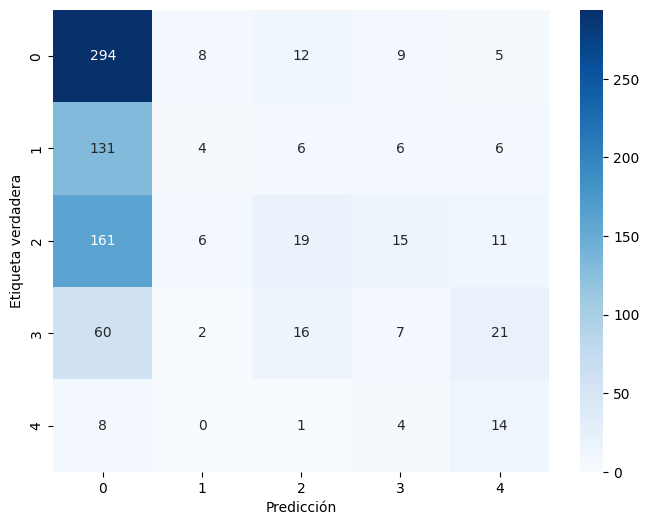

26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step
              precision    recall  f1-score   support

           0     0.4495    0.8963    0.5988       328
           1     0.2000    0.0261    0.0462       153
           2     0.3519    0.0896    0.1429       212
           3     0.1707    0.0660    0.0952       106
           4     0.2456    0.5185    0.3333        27

    accuracy                         0.4092       826
   macro avg     0.2835    0.3193    0.2433       826
weighted avg     0.3358    0.4092    0.3061       826



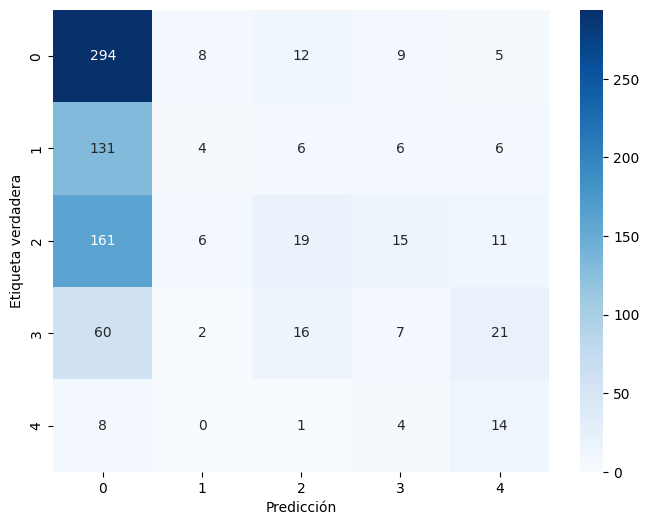

(<Sequential name=vit_transformer_custom_head, built=True>,
 <keras.src.callbacks.history.History at 0x7f1215d01840>)

In [20]:
"""
Capitulo 6

# Tarea 0 save model -> Fine Tuning
...
model.save('/kaggle/working/my_model.h5')
"""

regression = False
tarea = 0
frozen=False
finetuning=False
balanced=True
batch_size = 32

verbose=1

num_classes = 5
if regression:
    num_classes = 1
elif tarea == 1:
    num_classes = 3
elif tarea > 1:
    num_classes = 2

model = vit_transformer(num_classes=num_classes, regression=regression, frozen=frozen, pretrained = True)

entrenar_tarea(regression=regression, tarea=tarea, frozen=frozen, finetuning=finetuning, balanced=balanced, batch_size=batch_size, model=model)

In [21]:
model = keras.models.load_model('/kaggle/input/humankneet1/keras/default/1/humanKneeT1.keras')